In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid

# PHYSICAL CONSTANTS & PROPERTIES

In [2]:
R_gas      = 8.314          # Gas constant [J/mol/K]
kB         = 1.380649e-23   # Boltzmann constant [J/K]
m          = 2.99e-26       # Mass of water molecule [kg]
M          = 0.018          # Molar mass [kg/mol]
rho_l      = 1000.0         # Liquid density [kg/m3]
h_vap      = 2.5e6          # Latent heat [J/kg]
T_critical = 647.096        # Water critical temperature [K]
T_ref      = 293.15         # Reference temperature [K]
P_ref      = 101325.0       # Reference pressure [Pa]
D_v_ref    = 2.6e-5         # Water-vapor diffusivity in gas at T_ref, P_ref [m2/s]
d_molecule = 3.7e-10        # Effective molecular diameter for mean free path [m]

T_freeze        = 263.15    # Hard freeze backstop [K]
T_guard_min     = 200.0     # Lower numerical guard [K]
T_guard_max     = 373.15    # Upper numerical guard [K]
T_nucl_min      = 233.15    # Lower validity bound for nucleation fit [K]
T_property_min  = 235.0     # Lower validity bound for property correlations [K]
T_property_max  = 373.15    # Upper validity bound for property correlations [K]
r_guard_min     = 0.05e-6   # Smallest admissible jet radius [m]
delta_guard_max = 80.0      # Maximum admissible radial contrast [K]
T_critical_offset = 1e-6    # Offset to stay below the critical-point singularity [K]
sigma_min = 1e-4            # Lower guard for surface tension [N/m]
k_thermal_min = 0.15        # Lower guard for thermal conductivity [W/m/K]
wave_seed_fraction = 0.01   # Initial Rayleigh-wave amplitude / radius [-]
wave_amplitude_max = 0.9    # Maximum Rayleigh-wave amplitude / radius [-]
v_guard_min = 1e-12         # Lower guard for axial speed [m/s]


# OPERATING CONDITIONS

In [3]:
T_nozzle  = 293.15       # Nozzle temperature [K]
d_nozzle  = 20e-6        # Nozzle diameter [m]
Q_flow    = 0.6e-6 / 60  # Flow rate [m3/s]
P_chamber = 1e-5 * 100   # Chamber pressure [Pa]
P_back    = 0.0          # Gas-phase water-vapor back pressure [Pa]
T_gas     = 293.15       # Chamber gas temperature for gas transport [K]

r_nozzle    = d_nozzle / 2
A_nozzle    = np.pi * r_nozzle**2
v_nozzle    = Q_flow / A_nozzle
m_dot_total = rho_l * Q_flow

print("="*60)
print("INITIAL CONDITIONS")
print("="*60)
print(f"Nozzle diameter     : {d_nozzle*1e6:.1f} um")
print(f"Flow rate           : {Q_flow*60*1e6:.2f} uL/min")
print(f"Jet velocity        : {v_nozzle:.1f} m/s")
print(f"Chamber pressure    : {P_chamber:.2e} Pa ({P_chamber/100:.2e} mbar)")
print(f"Vapor back pressure : {P_back:.2e} Pa")
print(f"Nozzle temp         : {T_nozzle:.2f} K")
print(f"Gas temp            : {T_gas:.2f} K")


INITIAL CONDITIONS
Nozzle diameter : 20.0 um
Flow rate       : 0.60 uL/min
Jet velocity    : 31.8 m/s
Chamber pressure: 1.00e-03 Pa (1.00e-05 mbar)
Nozzle temp     : 293.15 K


# MODEL SWITCHES

In [4]:
# ── Toggle sub-models here ────────────────────────────────────────────────────

USE_RADIAL_PROFILE          = True
# Tracks T_surface and T_centerline via a parabolic Galerkin ODE.
# Evaporation and nucleation use T_surface (physically correct).
# Set False to recover the original 1-D isothermal cross-section model.

USE_SURFACE_WAVES           = True
# Multiplies evaporation flux by a Rayleigh-Plateau area correction factor
# (~2-4% effect near breakup). Set False to ignore.

USE_TEMP_DEPENDENT_PROPERTIES = True
# Uses temperature-dependent mu, sigma, cp_l and k_thermal.

USE_BACK_PRESSURE           = True
# Includes an imposed chamber-side water-vapor back pressure P_back.

USE_DIFFUSION_LIMIT         = True
# Combines Hertz-Knudsen and gas-phase diffusion resistances in series.

alpha_evap = 0.9
# Evaporation coefficient: 1.0 = ideal vacuum, 0.9 = recommended for
# turbo + LN2 trap at 1e-5 mbar.

print(f"USE_RADIAL_PROFILE          : {USE_RADIAL_PROFILE}")
print(f"USE_SURFACE_WAVES           : {USE_SURFACE_WAVES}")
print(f"USE_TEMP_DEPENDENT_PROPERTIES: {USE_TEMP_DEPENDENT_PROPERTIES}")
print(f"USE_BACK_PRESSURE           : {USE_BACK_PRESSURE}")
print(f"USE_DIFFUSION_LIMIT         : {USE_DIFFUSION_LIMIT}")
print(f"alpha_evap                  : {alpha_evap}")


USE_RADIAL_PROFILE : True
USE_SURFACE_WAVES  : True
alpha_evap         : 0.9


# HELPER FUNCTIONS

In [5]:
def clamp_temperature(T, low=T_guard_min, high=T_guard_max):
    return float(np.clip(T, low, high))


def liquid_heat_capacity(T):
    """Liquid-water cp [J/kg/K], polynomial fit over ~0-100 C, guarded below 0 C."""
    if not USE_TEMP_DEPENDENT_PROPERTIES:
        return 4200.0
    T_c = clamp_temperature(T, T_property_min, T_property_max) - 273.15
    cp = (4217.4
          - 3.720283 * T_c
          + 0.1412855 * T_c**2
          - 2.654387e-3 * T_c**3
          + 2.093236e-5 * T_c**4)
    return max(cp, 3000.0)


def liquid_surface_tension(T):
    """Surface tension of water [N/m], Vargaftik-type correlation."""
    if not USE_TEMP_DEPENDENT_PROPERTIES:
        return 0.072
    T_eval = clamp_temperature(T, T_property_min, T_critical - T_critical_offset)
    tau = max(1.0 - T_eval / T_critical, 1e-9)
    sigma = 0.2358 * tau**1.256 * (1.0 - 0.625 * tau)
    return max(sigma, sigma_min)


def liquid_thermal_conductivity(T):
    """Liquid-water thermal conductivity [W/m/K], guarded quadratic fit."""
    if not USE_TEMP_DEPENDENT_PROPERTIES:
        return 0.6
    T_c = clamp_temperature(T, T_property_min, T_property_max) - 273.15
    k_val = 0.561 + 1.93e-3 * T_c - 6.35e-6 * T_c**2
    return max(k_val, k_thermal_min)


def liquid_dynamic_viscosity(T):
    """Liquid-water viscosity [Pa s], Andrade/VFT-style fit over ~0-100 C."""
    if not USE_TEMP_DEPENDENT_PROPERTIES:
        return 1.0e-3
    T_c = clamp_temperature(T, T_property_min, T_property_max) - 273.15
    return 2.414e-5 * 10**(247.8 / (T_c + 133.15))


def antoine_pressure(T):
    """
    Vapor pressure over liquid water [Pa].
    Murphy & Koop (2005) eq. 10 — valid ~123 K to 332 K,
    including the supercooled regime. Replaces the old Antoine+clamp.
    """
    T_eval = clamp_temperature(T, 123.0, 332.0)
    ln_p = (54.842763
            - 6763.22  / T_eval
            - 4.210    * np.log(T_eval)
            + 0.000367 * T_eval
            + np.tanh(0.0415 * (T_eval - 218.8))
            * (53.878 - 1331.22 / T_eval - 9.44523 * np.log(T_eval) + 0.014025 * T_eval))
    return float(np.exp(ln_p))


In [6]:
def mean_free_path(T, P_total):
    """Approximate gas-phase mean free path [m]."""
    T_eval = clamp_temperature(T)
    P_eval = max(P_total, 1e-9)
    return kB * T_eval / (np.sqrt(2.0) * np.pi * d_molecule**2 * P_eval)


def diffusion_coefficient_vapor(T, P_total):
    """Approximate water-vapor diffusivity in the chamber gas [m2/s]."""
    T_eval = clamp_temperature(T)
    P_eval = max(P_total, 1e-9)
    return D_v_ref * (T_eval / T_ref)**1.75 * (P_ref / P_eval)


def hertz_knudsen_flux(T, alpha=1.0, P_vapor=0.0):
    """
    Evaporative mass flux [kg/m2/s] via Hertz-Knudsen equation.
    T should be the SURFACE temperature.
    """
    T_eval = clamp_temperature(T)
    P_sat = antoine_pressure(T_eval)
    delta_p = max(P_sat - max(P_vapor, 0.0), 0.0)
    return alpha * delta_p * np.sqrt(M / (2.0 * np.pi * R_gas * T_eval))


def diffusion_limited_flux(T_surface, r, P_total, P_vapor=0.0, T_gas_local=None, sh=1.0):
    """Gas-phase diffusion-limited evaporation flux [kg/m2/s]."""
    T_s = clamp_temperature(T_surface)
    T_inf = clamp_temperature(T_s if T_gas_local is None else T_gas_local)
    P_total = max(P_total, 1e-9)
    P_vapor = float(np.clip(P_vapor, 0.0, P_total))
    T_film = 0.5 * (T_s + T_inf)
    D_v = diffusion_coefficient_vapor(T_film, P_total)
    rho_v_surface = antoine_pressure(T_s) * M / (R_gas * T_s)
    rho_v_inf = P_vapor * M / (R_gas * T_inf)
    delta_rho = max(rho_v_surface - rho_v_inf, 0.0)
    return sh * D_v * delta_rho / max(r, r_guard_min)


def evaporation_flux_components(T_surface, r, alpha=1.0, P_total=0.0, P_vapor=0.0, T_gas_local=None):
    """Return net, Hertz-Knudsen, and diffusion-limited fluxes [kg/m2/s]."""
    P_total_eff = max(P_total, P_vapor, 1e-9)
    P_vapor_eff = P_vapor if USE_BACK_PRESSURE else 0.0
    gamma_hk = hertz_knudsen_flux(T_surface, alpha=alpha, P_vapor=P_vapor_eff)
    gamma_diff = diffusion_limited_flux(T_surface, r, P_total_eff, P_vapor=P_vapor_eff, T_gas_local=T_gas_local)
    if USE_DIFFUSION_LIMIT and gamma_hk > 0.0 and gamma_diff > 0.0:
        gamma_net = 1.0 / (1.0 / gamma_hk + 1.0 / gamma_diff)
    elif USE_DIFFUSION_LIMIT:
        gamma_net = 0.0
    else:
        gamma_net = gamma_hk
    return gamma_net, gamma_hk, gamma_diff


def knudsen_number(T, P_total, r):
    return mean_free_path(T, P_total) / max(r, r_guard_min)


def classify_knudsen_regime(Kn):
    if Kn > 10.0:
        return 'free-molecular'
    if Kn > 0.1:
        return 'transitional'
    return 'continuum'


In [7]:
def nucleation_rate(T):
    """
    Homogeneous ice nucleation rate J [m-3 s-1] in supercooled water.
    Knopf & Rigg (2011) / Atkinson et al. (2016) polynomial fit.
    Valid 233-273 K. Returns 0 above 273.15 K and clamps to the lower fit bound.
    """
    if T >= 273.15:
        return 0.0
    T_eval = max(T, T_nucl_min)
    log10_J = (-906.7
               + 8.502    * T_eval
               - 0.02657  * T_eval**2
               + 2.766e-5 * T_eval**3)
    return 10**log10_J * 1e6   # cm-3 s-1 -> m-3 s-1


In [8]:
def surface_wave_area_factor(r, z, v0, sigma_local):
    """
    Evaporation area correction from growing Rayleigh-Plateau waves.
    Most unstable mode k* = 0.697/r, initial amplitude = 1% of r.
    Returns 1.0 when USE_SURFACE_WAVES is False.
    """
    if not USE_SURFACE_WAVES:
        return 1.0
    r_eff = max(r, r_guard_min)
    k_star = 0.697 / r_eff
    omega = np.sqrt(sigma_local / (rho_l * r_eff**3)) * 0.343
    eps = min(wave_seed_fraction * r_eff * np.exp(omega * z / max(v0, v_guard_min)),
              wave_amplitude_max * r_eff)
    return 1.0 + 0.5 * (eps * k_star)**2


In [9]:
def rayleigh_breakup_length(r0, v0, T_ref_local=None):
    """Estimate breakup length via Rayleigh-Plateau instability."""
    T_eval = T_nozzle if T_ref_local is None else T_ref_local
    sigma_local = liquid_surface_tension(T_eval)
    mu_local = liquid_dynamic_viscosity(T_eval)
    We = rho_l * v0**2 * (2 * r0) / sigma_local
    Oh = mu_local / np.sqrt(rho_l * sigma_local * 2 * r0)
    omega = np.sqrt(sigma_local / (rho_l * r0**3))
    tb = np.log(1e4) / omega
    return v0 * tb, tb, We, Oh


# DIAGNOSTICS

In [10]:
L_breakup, t_breakup, We, Oh = rayleigh_breakup_length(r_nozzle, v_nozzle, T_nozzle)
Re = rho_l * v_nozzle * d_nozzle / liquid_dynamic_viscosity(T_nozzle)

cp_nozzle = liquid_heat_capacity(T_nozzle)
sigma_nozzle = liquid_surface_tension(T_nozzle)
k_nozzle = liquid_thermal_conductivity(T_nozzle)
gamma_0, gamma_hk_0, gamma_diff_0 = evaporation_flux_components(
    T_nozzle,
    r_nozzle,
    alpha=alpha_evap,
    P_total=P_chamber,
    P_vapor=P_back,
    T_gas_local=T_gas,
)
alpha_th = k_nozzle / (rho_l * cp_nozzle)
Fo_breakup = alpha_th * (L_breakup / v_nozzle) / r_nozzle**2
L_relax = rho_l * cp_nozzle * v_nozzle * r_nozzle**2 / (8 * k_nozzle)
DeltaT_qs = gamma_0 * h_vap * r_nozzle / (4 * k_nozzle)
Kn_nozzle = knudsen_number(T_gas, P_chamber, r_nozzle)

print("="*60)
print("DIAGNOSTICS")
print("="*60)
print(f"Net evap flux at nozzle: {gamma_0:.2e} kg/m2/s")
print(f"  HK limit             : {gamma_hk_0:.2e} kg/m2/s")
print(f"  Diffusion limit      : {gamma_diff_0:.2e} kg/m2/s")
print(f"Cooling rate (1-D)     : {2*gamma_0*h_vap/(rho_l*v_nozzle*r_nozzle*cp_nozzle):.2e} K/m")
print(f"Re={Re:.0f}  We={We:.2f}  Oh={Oh:.4f}")
print(f"Rayleigh breakup       : {L_breakup*1e3:.2f} mm  ({t_breakup*1e6:.1f} us)")
print(f"Fourier no. at breakup : {Fo_breakup:.3f}  (>1=isothermal, <0.1=strong gradient)")
print(f"Delta relaxation len   : {L_relax*1e3:.2f} mm")
print(f"Quasi-steady dT_surf   : {DeltaT_qs:.1f} K below mean")
print(f"Knudsen number         : {Kn_nozzle:.2e} ({classify_knudsen_regime(Kn_nozzle)})")
print(f"sigma(T_nozzle)        : {sigma_nozzle:.4f} N/m")
print(f"mu(T_nozzle)           : {liquid_dynamic_viscosity(T_nozzle):.3e} Pa s")
print(f"cp(T_nozzle)           : {cp_nozzle:.1f} J/kg/K")
print(f"k(T_nozzle)            : {k_nozzle:.3f} W/m/K")


DIAGNOSTICS
Evap flux at nozzle   : 2.28e+00 kg/m2/s
Cooling rate (1-D)    : 8.54e+03 K/m
Re=637  We=281.45  Oh=0.0264
Rayleigh breakup      : 1.09 mm  (34.3 us)
Fourier no. at breakup: 0.049  (>1=isothermal, <0.1=strong gradient)
Delta relaxation len  : 2.79 mm
Quasi-steady dT_surf  : 23.8 K below mean


# ODE SYSTEM

In [11]:
def unpack_state(y):
    if USE_RADIAL_PROFILE:
        T_mean, r, Delta = y
    else:
        T_mean, r = y
        Delta = 0.0
    return float(T_mean), float(r), float(Delta)


def surface_temperature_from_state(y):
    T_mean, _, Delta = unpack_state(y)
    return T_mean - Delta / 2


def guard_state(y):
    T_mean, r, Delta = unpack_state(y)
    T_mean = clamp_temperature(np.nan_to_num(T_mean, nan=T_guard_min, posinf=T_guard_max, neginf=T_guard_min))
    r = np.nan_to_num(r, nan=r_guard_min, posinf=r_guard_min, neginf=r_guard_min)
    r = max(r, r_guard_min)
    Delta = np.nan_to_num(Delta, nan=0.0, posinf=delta_guard_max, neginf=0.0)
    Delta = float(np.clip(Delta, 0.0, delta_guard_max))
    T_surface = clamp_temperature(T_mean - Delta / 2)
    T_center = clamp_temperature(T_mean + Delta / 2)
    return T_mean, r, Delta, T_surface, T_center


def jet_ode(z, y):
    """
    State vector:
      USE_RADIAL_PROFILE=False : y = [T_mean, r]
        Standard 1-D model; T_surface = T_mean everywhere.

      USE_RADIAL_PROFILE=True  : y = [T_mean, r, Delta]
        Delta = T_centerline - T_surface  (always >= 0)
        Derived from parabolic-mode Galerkin projection of the
        radial heat equation with evaporative surface flux BC:

            dDelta/dz = 2*q_s/(rho*cp*v*r) - 8*k*Delta/(rho*cp*v*r^2)

        T_surface = T_mean - Delta/2
        T_center  = T_mean + Delta/2

    Evaporation and nucleation always use T_surface.
    """
    T_mean, r, Delta, T_surface, _ = guard_state(y)
    cp_local = liquid_heat_capacity(T_mean)
    k_local = liquid_thermal_conductivity(T_mean)
    sigma_local = liquid_surface_tension(T_surface)

    wave = surface_wave_area_factor(r, z, v_nozzle, sigma_local)
    gamma_base, _, _ = evaporation_flux_components(
        T_surface,
        r,
        alpha=alpha_evap,
        P_total=P_chamber,
        P_vapor=P_back,
        T_gas_local=T_gas,
    )
    gamma = gamma_base * wave
    q_s = gamma * h_vap

    dTmeandz = -2 * q_s / (rho_l * v_nozzle * r * cp_local)
    drdz = -gamma / (rho_l * v_nozzle)

    if USE_RADIAL_PROFILE:
        dDeltadz = (2 * q_s / (rho_l * cp_local * v_nozzle * r)
                    - 8 * k_local * Delta / (rho_l * cp_local * v_nozzle * r**2))
        return [dTmeandz, drdz, dDeltadz]
    else:
        return [dTmeandz, drdz]


def freeze_event(z, y):
    """Hard freeze backstop: T_surface hits T_freeze."""
    return surface_temperature_from_state(y) - T_freeze

freeze_event.terminal = True
freeze_event.direction = -1


def breakup_event(z, y):
    """Terminate at predicted Rayleigh breakup — only laminar section is physical."""
    return z - L_breakup

breakup_event.terminal = True
breakup_event.direction = -1


def radius_guard_event(z, y):
    """Terminate if the radius collapses to a nonphysical value."""
    return unpack_state(y)[1] - r_guard_min

radius_guard_event.terminal = True
radius_guard_event.direction = -1


def temperature_guard_event(z, y):
    """Terminate before the temperature leaves the guarded model range."""
    return surface_temperature_from_state(y) - T_guard_min

temperature_guard_event.terminal = True
temperature_guard_event.direction = -1


def delta_guard_event(z, y):
    """Terminate if the radial temperature contrast becomes too large."""
    return delta_guard_max - unpack_state(y)[2]


delta_guard_event.terminal = True
delta_guard_event.direction = -1


# SOLVE

In [12]:
print("\n" + "="*60)
print("SOLVING JET ODE")
print("="*60)

y0 = [T_nozzle, r_nozzle, 0.0] if USE_RADIAL_PROFILE else [T_nozzle, r_nozzle]

event_list = [freeze_event, breakup_event, radius_guard_event, temperature_guard_event, delta_guard_event]
sol = solve_ivp(
    jet_ode,
    (0, 0.05),
    y0,
    events=event_list,
    max_step=5e-6,
    dense_output=True,
    rtol=1e-6, atol=1e-9
)

z = sol.t
T_mean = sol.y[0]
r = sol.y[1]

if USE_RADIAL_PROFILE:
    Delta = sol.y[2]
    T_surface = np.clip(T_mean - Delta / 2, T_guard_min, T_guard_max)
    T_center = np.clip(T_mean + Delta / 2, T_guard_min, T_guard_max)
else:
    Delta = np.zeros_like(T_mean)
    T_surface = np.clip(T_mean, T_guard_min, T_guard_max)
    T_center = T_surface.copy()

froze = sol.status == 1 and len(sol.t_events[0]) > 0
broke = sol.status == 1 and len(sol.t_events[1]) > 0
radius_guard_hit = sol.status == 1 and len(sol.t_events[2]) > 0
temperature_guard_hit = sol.status == 1 and len(sol.t_events[3]) > 0
delta_guard_hit = sol.status == 1 and len(sol.t_events[4]) > 0
z_end = z[-1]

if froze:
    print(f"Jet FROZE at z = {sol.t_events[0][0]*1e3:.2f} mm  (T_surface reached {T_freeze:.1f} K)")
elif broke:
    print(f"Integration stopped at BREAKUP: z = {z_end*1e3:.2f} mm")
elif radius_guard_hit:
    print(f"Integration stopped at RADIUS GUARD: z = {z_end*1e3:.2f} mm")
elif temperature_guard_hit:
    print(f"Integration stopped at TEMPERATURE GUARD: z = {z_end*1e3:.2f} mm")
elif delta_guard_hit:
    print(f"Integration stopped at DELTA GUARD: z = {z_end*1e3:.2f} mm")
else:
    print(f"Reached max integration length: {z_end*1e3:.2f} mm")

print(f"\nAt z = {z_end*1e3:.2f} mm:")
print(f"  T_mean    = {T_mean[-1]:.2f} K")
print(f"  T_surface = {T_surface[-1]:.2f} K")
print(f"  T_center  = {T_center[-1]:.2f} K")
print(f"  Delta     = {Delta[-1]:.2f} K")
print(f"  r         = {r[-1]*1e6:.3f} um")

gamma_components = np.array([
    evaporation_flux_components(Ts, rr, alpha=alpha_evap, P_total=P_chamber, P_vapor=P_back, T_gas_local=T_gas)
    for Ts, rr in zip(T_surface, r)
])
gamma_arr = gamma_components[:, 0]
gamma_hk_arr = gamma_components[:, 1]
gamma_diff_arr = gamma_components[:, 2]

m_evap_rate = 2 * np.pi * r * gamma_arr
m_evap_rate_hk = 2 * np.pi * r * gamma_hk_arr
m_evap_rate_diff = 2 * np.pi * r * gamma_diff_arr
M_dot_evap = np.trapezoid(m_evap_rate, z)
print(f"\nTotal evaporation rate: {M_dot_evap*1e9:.3f} ng/s")



SOLVING JET ODE
Jet FROZE at z = 9.65 mm  (T_surface reached 263.1 K)

At z = 9.65 mm:
  T_mean    = 265.57 K
  T_surface = 263.15 K
  T_center  = 267.98 K
  Delta     = 4.83 K
  r         = 9.771 um

Total evaporation rate: 400.397 ng/s


# NUCLEATION SURVIVAL CURVE

In [13]:
# P_survival(z) = exp( -integral_0^z  J(T_surface) * pi*r^2 / v  dz' )
#
# J rises steeply once T_surface dips into the supercooled regime.
# z_50 = median freeze position (50% of jets have nucleated).
# z_10 / z_90 = 10th / 90th percentile freeze positions.

J_arr = np.array([nucleation_rate(Ts) for Ts in T_surface])
integrand = J_arr * np.pi * r**2 / v_nozzle   # [m-1]
cum_integral = np.zeros_like(z)
cum_integral[1:] = cumulative_trapezoid(integrand, z)
P_survival = np.exp(-cum_integral)


def find_z_at_prob(P_target):
    """Position where P_survival first drops to P_target."""
    idx = np.searchsorted(-P_survival, -P_target)
    return z[idx] if idx < len(z) else float('nan')


def fmt_mm(val):
    return f"{val*1e3:.2f} mm" if np.isfinite(val) else "not reached"


def fmt_range_mm(values_mm):
    finite = values_mm[np.isfinite(values_mm)]
    if finite.size == 0:
        return "not reached"
    return f"{finite.min():.2f} - {finite.max():.2f} mm"


def status_line(label, ok, ok_detail, warn_detail=None):
    detail = ok_detail if ok else (warn_detail or ok_detail)
    tag = "OK" if ok else "WARN"
    return f"{tag:<4} {label:<18} {detail}"


z_10 = find_z_at_prob(0.90)   # 10% of jets have frozen
z_50 = find_z_at_prob(0.50)   # median
z_90 = find_z_at_prob(0.10)   # 90% of jets have frozen

print("\n" + "="*60)
print("NUCLEATION STATISTICS  (CNT, homogeneous)")
print("="*60)
print(f"z_10 (10% frozen) : {fmt_mm(z_10)}")
print(f"z_50 (median)     : {fmt_mm(z_50)}")
print(f"z_90 (90% frozen) : {fmt_mm(z_90)}")
print(f"P_survival at end : {P_survival[-1]:.4f}")



NUCLEATION STATISTICS  (CNT, homogeneous)
z_10 (10% frozen) : not reached
z_50 (median)     : not reached
z_90 (90% frozen) : not reached
P_survival at end : 1.0000


# PARAMETRIC STUDY: freeze position vs T_nozzle

In [14]:
T_range = np.linspace(274, 293, 25)
z50_arr = []
z_hard_arr = []
L_breakup_arr = []

for T_init in T_range:
    y0p = [T_init, r_nozzle, 0.0] if USE_RADIAL_PROFILE else [T_init, r_nozzle]
    L_breakup_i, _, _, _ = rayleigh_breakup_length(r_nozzle, v_nozzle, T_init)
    L_breakup_arr.append(L_breakup_i * 1e3)
    s = solve_ivp(
        jet_ode,
        (0, 0.05),
        y0p,
        events=event_list,
        max_step=5e-6,
        rtol=1e-6,
        atol=1e-9,
    )

    if s.status == 1 and len(s.t_events[0]) > 0:
        z_hard_arr.append(s.t_events[0][0] * 1e3)
    else:
        z_hard_arr.append(float('nan'))

    zp = s.t
    Tsp = np.clip((s.y[0] - s.y[2] / 2) if USE_RADIAL_PROFILE else s.y[0], T_guard_min, T_guard_max)
    rp = np.maximum(s.y[1], r_guard_min)
    Jp = np.array([nucleation_rate(T) for T in Tsp])
    ig = Jp * np.pi * rp**2 / v_nozzle
    ci = np.zeros_like(zp)
    ci[1:] = cumulative_trapezoid(ig, zp)
    Ps = np.exp(-ci)
    idx = np.searchsorted(-Ps, -0.5)
    z50_arr.append(zp[idx] * 1e3 if idx < len(zp) else float('nan'))

z50_arr = np.array(z50_arr)
z_hard_arr = np.array(z_hard_arr)
L_breakup_arr = np.array(L_breakup_arr)
print(f"Parametric study done. CNT z50 range: {fmt_range_mm(z50_arr)}")


Parametric study done. CNT z50 range: nan - nan mm


C:\Users\filip\AppData\Local\Temp\ipykernel_3492\3968700885.py:31: RuntimeWarning: All-NaN slice encountered
  print(f"Parametric study done. CNT z50 range: {np.nanmin(z50_arr):.2f} - {np.nanmax(z50_arr):.2f} mm")


# MASS EVAPORATED VS TIME

In [15]:
t_hours = np.linspace(0, 10, 500)
M_evap_t = M_dot_evap * t_hours * 3600   # kg


# PLOTTING

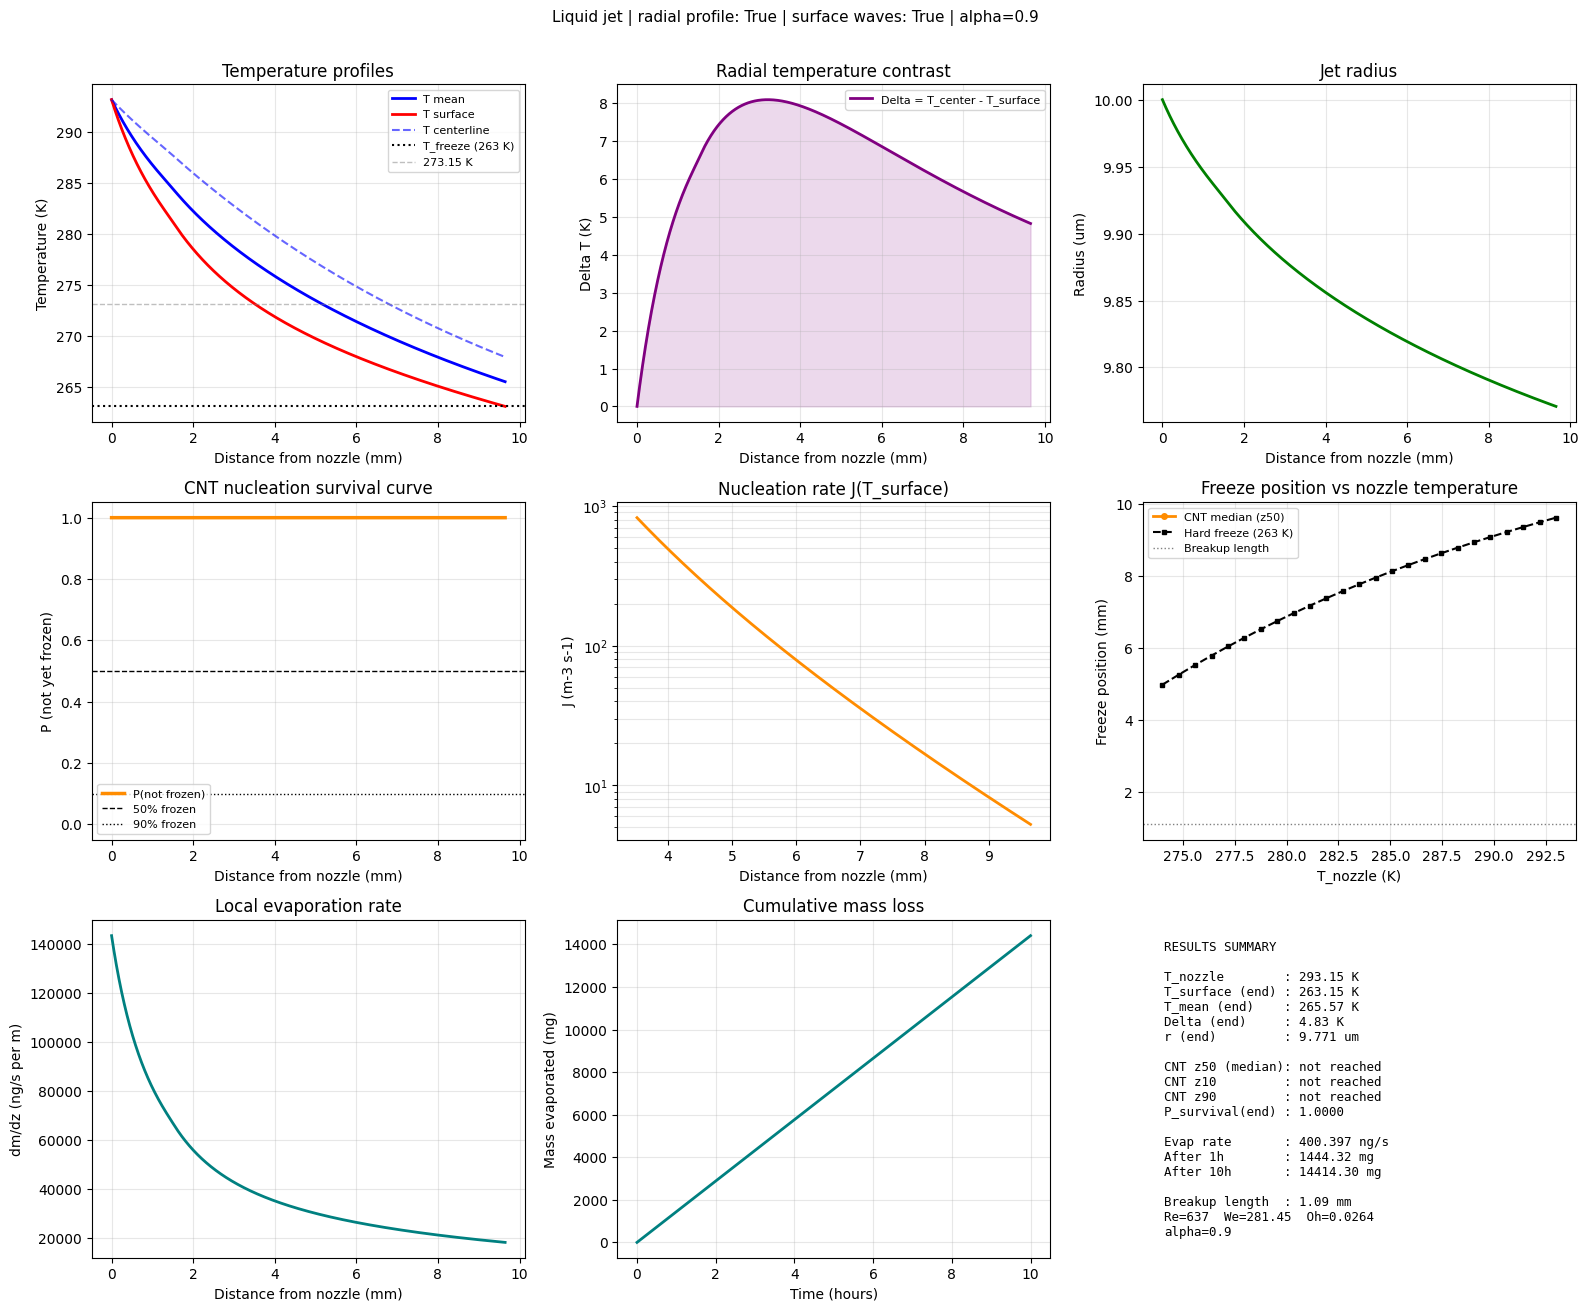

Saved jet_analysis.png


In [16]:
Kn_end = knudsen_number(T_gas, P_chamber, r[-1])
within_breakup = z_end <= L_breakup + 1e-12
property_temp_ok = T_surface.min() >= T_property_min and T_surface.max() <= T_property_max
nucleation_fit_ok = T_surface.min() >= T_nucl_min
pressure_inputs_ok = 0.0 <= P_back <= max(P_chamber, 0.0)
guards_ok = not any([radius_guard_hit, temperature_guard_hit, delta_guard_hit])

validity_lines = [
    status_line('Breakup window', within_breakup,
                f'end point {z_end*1e3:.2f} mm is within {L_breakup*1e3:.2f} mm',
                f'end point {z_end*1e3:.2f} mm exceeds {L_breakup*1e3:.2f} mm'),
    status_line('Property ranges', property_temp_ok,
                f'T_surface in [{T_surface.min():.1f}, {T_surface.max():.1f}] K',
                f'T_surface left [{T_property_min:.0f}, {T_property_max:.0f}] K fit range'),
    status_line('Nucleation fit', nucleation_fit_ok,
                f'min T_surface = {T_surface.min():.1f} K',
                f'T_surface went below {T_nucl_min:.1f} K fit bound'),
    status_line('Pressure inputs', pressure_inputs_ok,
                f'P_back/P_chamber = {P_back/max(P_chamber, 1e-12):.2f}',
                'Require 0 <= P_back <= P_chamber'),
    status_line('Solver guards', guards_ok,
                'no numerical guard triggered',
                'radius/temperature/Delta guard triggered'),
    status_line('Gas regime @ nozzle', True,
                f'Kn = {Kn_nozzle:.2e} ({classify_knudsen_regime(Kn_nozzle)})'),
    status_line('Gas regime @ end', True,
                f'Kn = {Kn_end:.2e} ({classify_knudsen_regime(Kn_end)})'),
]

summary_lines = [
    'RESULTS SUMMARY',
    '',
    f'T_nozzle             : {T_nozzle:.2f} K',
    f'P_chamber            : {P_chamber:.2e} Pa',
    f'P_back               : {P_back:.2e} Pa',
    f'T_surface (end)      : {T_surface[-1]:.2f} K',
    f'T_mean (end)         : {T_mean[-1]:.2f} K',
    f'Delta (end)          : {Delta[-1]:.2f} K',
    f'r (end)              : {r[-1]*1e6:.3f} um',
    '',
    f'CNT z50 (median)     : {fmt_mm(z_50)}',
    f'CNT z10              : {fmt_mm(z_10)}',
    f'CNT z90              : {fmt_mm(z_90)}',
    f'Parametric CNT z50   : {fmt_range_mm(z50_arr)}',
    f'P_survival(end)      : {P_survival[-1]:.4f}',
    '',
    f'Net evap rate        : {M_dot_evap*1e9:.3f} ng/s',
    f'After 1 h            : {M_evap_t[np.searchsorted(t_hours, 1.0)]*1e6:.2f} mg',
    f'After 10 h           : {M_evap_t[-1]*1e6:.2f} mg',
    '',
    'MODEL VALIDITY',
    *validity_lines,
]
summary = '\n'.join(summary_lines)

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle(
    f"Liquid jet model | P_chamber={P_chamber:.2e} Pa | P_back={P_back:.2e} Pa | "
    f"radial profile={USE_RADIAL_PROFILE} | surface waves={USE_SURFACE_WAVES} | T-dependent props={USE_TEMP_DEPENDENT_PROPERTIES}",
    fontsize=11, y=1.01
)

# ── 1: Temperature profiles ───────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(z*1e3, T_mean, 'b-', lw=2, label='Mean liquid T')
ax.plot(z*1e3, T_surface, 'r-', lw=2, label='Surface T')
ax.plot(z*1e3, T_center, 'b--', lw=1.5, alpha=0.6, label='Centerline T')
ax.axhline(T_freeze, color='k', ls=':', lw=1.5, label=f'Freeze backstop ({T_freeze:.0f} K)')
ax.axhline(273.15, color='gray', ls='--', lw=1, alpha=0.5, label='273.15 K')
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('Temperature (K)')
ax.set_title('Liquid temperature evolution')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 2: Radial delta T ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(z*1e3, Delta, 'purple', lw=2, label='Delta = T_center - T_surface')
ax.fill_between(z*1e3, 0, Delta, alpha=0.15, color='purple')
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('Delta T (K)')
ax.set_title('Radial temperature contrast')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
if not USE_RADIAL_PROFILE:
    ax.text(0.5, 0.5, 'Radial profile OFF', transform=ax.transAxes,
            ha='center', va='center', color='gray', fontsize=12)

# ── 3: Jet radius ─────────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(z*1e3, r*1e6, 'g-', lw=2)
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('Radius (um)')
ax.set_title('Jet radius evolution')
ax.grid(alpha=0.3)

# ── 4: CNT survival curve ─────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(z*1e3, P_survival, 'darkorange', lw=2.5, label='P(not frozen)')
ax.axhline(0.5, color='k', ls='--', lw=1, label='50% frozen')
ax.axhline(0.1, color='k', ls=':', lw=1, label='90% frozen')
for zv, lab in [(z_10, 'z10'), (z_50, 'z50 (median)'), (z_90, 'z90')]:
    if np.isfinite(zv):
        ax.axvline(zv*1e3, color='darkorange', ls=':', lw=1, alpha=0.8)
        ax.text(zv*1e3 + 0.05, 0.55, lab, fontsize=8, color='darkorange')
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('Survival probability (-)')
ax.set_title('CNT survival curve')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# ── 5: Nucleation rate ────────────────────────────────────────────────────────
ax = axes[1, 1]
mask = J_arr > 0
if mask.any():
    ax.semilogy(z[mask]*1e3, J_arr[mask], 'darkorange', lw=2)
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('J (m-3 s-1)')
ax.set_title('Homogeneous nucleation rate')
ax.grid(alpha=0.3, which='both')

# ── 6: Parametric freeze position vs T_nozzle ────────────────────────────────
ax = axes[1, 2]
ax.plot(T_range, z50_arr, 'darkorange', lw=2, marker='o', ms=4, label='CNT median z50')
ax.plot(T_range, z_hard_arr, 'k--', lw=1.5, marker='s', ms=3, label=f'Hard freeze ({T_freeze:.0f} K)')
ax.plot(T_range, L_breakup_arr, color='gray', ls=':', lw=1.5, label='Predicted breakup length')
ax.set_xlabel('Nozzle temperature, T_nozzle (K)')
ax.set_ylabel('Axial position (mm)')
ax.set_title('Freeze position vs nozzle temperature')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 7: Local evaporation rate ─────────────────────────────────────────────────
ax = axes[2, 0]
ax.plot(z*1e3, m_evap_rate*1e9, 'teal', lw=2, label='Net')
ax.plot(z*1e3, m_evap_rate_hk*1e9, color='slateblue', ls='--', lw=1.5, label='Hertz-Knudsen limit')
ax.plot(z*1e3, m_evap_rate_diff*1e9, color='gray', ls=':', lw=1.5, label='Diffusion limit')
ax.set_xlabel('Axial distance, z (mm)')
ax.set_ylabel('dmdot_evap/dz (ng s-1 m-1)')
ax.set_title('Local evaporation-rate limits')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 8: Cumulative mass loss ───────────────────────────────────────────────────
ax = axes[2, 1]
ax.plot(t_hours, M_evap_t*1e6, 'teal', lw=2)
ax.set_xlabel('Elapsed time (h)')
ax.set_ylabel('Equivalent evaporated mass (mg)')
ax.set_title('Mass loss extrapolated from the steady net rate')
ax.grid(alpha=0.3)

# ── 9: Summary table ──────────────────────────────────────────────────────────
ax = axes[2, 2]
ax.axis('off')
ax.set_title('Results and model validity')
ax.text(0.02, 0.98, summary, fontsize=8.5, family='monospace',
        va='top', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('jet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved jet_analysis.png')
